# Slotted graphite-slab MSR core cell — OpenMC CSG model + Latin-hypercube study

**Concept (Brian):** graphite slabs with **vertical fuel slots** alternating with **horizontal coolant slots**.
Both slot types are milled with the **same profile**: `slot_width` × `slot_depth`, flat on the mouth side and
**rounded on one side only, radius = `slot_depth`** (reflects how the slots are machined). Slots are separated by
graphite **webs** (`web_thickness`); slabs are isolated from each other by a graphite **wall** (`wall_thickness`).

This notebook:
1. defines the geometry with OpenMC CSG (`build_model(slot_width, slot_depth, web_thickness, wall_thickness, **opts)`),
2. plots it (xy / xz / yz slices, coloured by material),
3. checks the CSG volumes against closed-form area formulas,
4. runs the first model (finite cylindrical core, R = 70 cm, H = 2R, MSRE fuel salt) and a quick unit-cell k-inf,
5. sets up a Latin-hypercube sweep over the four parameters (`scipy.stats.qmc.LatinHypercube`; enrichment and core radius optional),
   with transport switched by `RUN_TRANSPORT` (finite-cylinder k-eff by default).

Everything is in this notebook (no helper modules needed). Tested with OpenMC 0.16.0, SciPy 1.18, pandas 3.0.

## Geometry interpretation & assumptions  (edit here first if anything is wrong)

**Axes:** `x` = slab-thickness / stacking direction, `y` = horizontal in the slab plane, `z` = vertical.

**Through the thickness (x) of one slab** the slot rows alternate, separated by webs; slabs are separated by a wall:

```
 x ──►   |<──────────────────────── one slab ─────────────────────────>|<-wall->|
         | F-row |  web  | C-row |  web  | F-row |  web  | C-row |      | graphite| F-row ...
         |<-d-->|<t_web>|<-d-->|<t_web>|<-d-->|<t_web>|<-d-->|      |<t_wall>|
   F-row = row of vertical fuel slots   (run along z, width along y, pitch w + t_web in y)
   C-row = row of horizontal coolant slots (run along y, width along z, pitch w + t_web in z)
   n_slot_pairs = number of (F,C) pairs per slab  (default 2, as drawn)
```

**Shared milled-slot profile** (one function `milled_slot_region()` builds both slot types, just oriented differently):

```
  u (across width) ──►
  0                w-d        w
  +=================+=========+   <- mouth: flat, open face (closed by the neighbouring web/wall graphite)
  |                 |       .'
  |      salt       |    .'        one side wall is a quarter-round of radius R = d,
  |                 | .'           centre on the mouth plane at u = w-d
  +-----------------+'            <- flat bottom, width w-d, at depth v = d
  v (depth into graphite, +x)
```
* Fuel slot: this profile in the **x–y** plane, extruded along **z** (vertical). Coolant slot: same profile in the **x–z** plane, extruded along **y** (horizontal).
* CSG: `slot = [rectangle (w-d) × d]  ∪  [cylinder(R=d, axis = run direction, centred on the mouth plane) ∩ (depth ≥ 0) ∩ (u ≥ w-d)]`.
  Graphite = complement of all slots. Cross-section area `A = (w-d)·d + π d²/4`.
* **Why this reading:** "rounded only on one side, radius = depth" is what a cutter with a radius-`d` flank leaves
  (e.g. a ball-nose/radius cutter of radius `d` plunged to full depth along one edge, square end mill clearing the rest).
  The arc is centred on the mouth plane so the slot is widest at the mouth → no undercut, machinable from the open face.
  Consequence / constraint: **`slot_width ≥ slot_depth`** (at `w = d` the slot is a pure quarter-circle). Infeasible LHS samples are filtered.
* **Flags for the alternatives:**
  * `round_location="side"` (default, above) · `"bottom"` = U-groove: flat parallel sides, arc bottom of radius `d` centred on the
    mouth mid-width (needs `w ≤ 2d`; `w = 2d` is a half-round) · `"none"` = square slot (reference).
  * `fuel_round_side` / `coolant_round_side` = `"+"` or `"-"`: which lateral side carries the radius (+y/−y for fuel, +z/−z for coolant).
* **Not modelled:** the run-out radius at the *ends* of a slot (where a cutter enters/exits along its run direction).
  The unit cell is infinite along the slot run direction; in the finite model slots simply end at the slab boundary (plugged by the reflector).

**Other assumptions (placeholders — change freely):**
* All slots open toward −x (mouth on the −x face of each slot row) and are closed by the next graphite layer; i.e. a slab is a stack of
  milled plates of thickness `d + t_web`. Mouth direction does not affect volume fractions.
* `web_thickness` is used both between slot rows (in x) **and** between neighbouring slots in the same row (in y / z).
  Pass `inplane_web=` to decouple the in-row land from the through-thickness web.
* `wall_thickness` = total graphite between the last slot row of one slab and the first of the next (one shared wall in the periodic cell).
  If each slab has its own skin of thickness `t`, use `wall_thickness = 2t`.
* Fuel and coolant slots use the **same** width, depth and profile (as described). Unit cell pitch: `P_x = 2n·d + (2n−1)·t_web + t_wall`,
  `P_y = P_z = w + t_web`.
* **Default model = finite cylindrical core** (`mode="cylinder"`): a `RectLattice` of the unit-cell universe (odd count per axis,
  a unit cell centred on the axis) is truncated by a `ZCylinder` of radius `R = core_radius` (default **70 cm**, ~MSRE core radius)
  and z-planes at ±R (**H = 2R = D**). Vacuum boundary; optional graphite reflector `reflector_thickness` (default 0, bare core).
  Slots are simply cut off at the cylinder surface (salt in the partial slots at the boundary is kept; no plenums, no vessel,
  no downcomer, no inlet/outlet headers — so **the fuel salt outside the core is not modelled**).
  `mode="unit_cell"` = one unit cell with periodic boundaries on all six faces → k-infinity (quick mode).
* Materials at 922 K (MSRE operating temperature): **fuel = MSRE 235U-operation fuel salt** 7LiF-BeF₂-ZrF₄-UF₄ 65.0-29.17-5.0-0.83 mol%,
  33.477 wt% U-235 (variable `ENRICHMENT`), 99.995 % Li-7, ρ = 2.575 − 5.13·10⁻⁴·T[°C] g/cc (ORNL sources cited in §2);
  coolant = MSRE coolant salt 7LiF-BeF₂ 66-34 mol%; graphite 1.87 g/cc + `c_Graphite` S(α,β).
  No structural tube walls/liners are modelled — the salt wets the graphite directly.

In [1]:
# ---- user switches -----------------------------------------------------------------------------------
import os, math, json, shutil, warnings, re, time, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import openmc
from scipy.stats import qmc

WORK_DIR = os.path.abspath(os.environ.get("MSR_WORK_DIR", "."))      # PNGs / CSV / run dirs go here
RUN_KINF       = True      # quick unit-cell k-infinity run of the default geometry (~1 min)
RUN_BASELINE   = True      # finite-cylinder k-eff run of the default geometry (the "first model")
RUN_TRANSPORT  = False     # transport for every LHS sample (set True for the sweep; skipped without nuclear data)
PARTICLES, BATCHES, INACTIVE = 10000, 100, 40   # finite core: 600k active histories -> k std ~100 pcm
# all transport steps are skipped automatically if no cross_sections.xml is found

# ---- core --------------------------------------------------------------------------------------------------
MODE = "cylinder"          # "cylinder" (finite core, H = 2R, vacuum boundary) or "unit_cell" (periodic, k-inf)
CORE_RADIUS = 70.0         # cm; H = 2R = 140 cm.  (MSRE graphite core radius was 70.2 cm - IRPhEP benchmark)
REFLECTOR_THICKNESS = 0.0  # cm of graphite around the cylinder (side, top, bottom); 0 = bare core
THREADS = None             # None = all OpenMP threads

# ---- fuel ------------------------------------------------------------------------------------------------
ENRICHMENT = 33.477        # U-235 WEIGHT % of total uranium. Default = MSRE 235U operation (ORNL-4658 Table 2.8)
TEMPERATURE_K = 922.0      # material temperature (MSRE operating ~650 C); salt densities follow ORNL correlations

import sys
if shutil.which("openmc") is None:                 # make the conda env's `openmc` executable visible to model.run()
    os.environ["PATH"] = os.path.join(sys.prefix, "bin") + os.pathsep + os.environ.get("PATH", "")
USE_NUCLEAR_DATA = os.environ.get("MSR_USE_XS", "1") == "1"   # set False to force the no-data path

# nuclear data: $OPENMC_CROSS_SECTIONS or first existing candidate below
for _xs in ([] if not USE_NUCLEAR_DATA else [os.environ.get("OPENMC_CROSS_SECTIONS"),
            os.path.expanduser("~/nucdata/endfb-viii.0-hdf5/cross_sections.xml"),
            "/workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml"]):
    if _xs and os.path.exists(_xs):
        openmc.config["cross_sections"] = _xs
        break
if not USE_NUCLEAR_DATA:
    openmc.config.pop("cross_sections", None)
HAVE_XS = openmc.config.get("cross_sections") is not None and os.path.exists(str(openmc.config.get("cross_sections")))
print("OpenMC", openmc.__version__, "| cross sections:", openmc.config.get("cross_sections") if HAVE_XS else "NOT FOUND (transport skipped, python plot fallback)")
print("WORK_DIR =", WORK_DIR)

OpenMC 0.16.0 | cross sections: /workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml
WORK_DIR = /workspace/msr_slab


## 1. Shared milled-slot profile (fuel **and** coolant)

In [2]:
# 1. Shared milled-slot profile (used for BOTH fuel and coolant slots)
#   local 2-D coords of the slot cross-section:
#     u = across the slot width (0 .. w),  v = depth measured from the mouth (0 .. d)
#   round_location:
#     "side"   : (default) one lateral side wall is a quarter-round of radius R = d
#                whose centre lies on the MOUTH plane at u = w-d  ->  slot is w wide at
#                the mouth, (w-d) wide at the flat bottom.  Needs w >= d.
#     "bottom" : flat parallel sides, bottom is an arc of radius R = d centred on the
#                mouth plane at mid-width (U / ball-nose groove). Needs w <= 2d.
#     "none"   : plain rectangle w x d (reference case, no radius).
#   round_side: "+" -> rounded wall is at the high-u side, "-" -> low-u side.

def profile_area(w, d, round_location="side"):
    if round_location == "side":
        return (w - d) * d + math.pi * d**2 / 4.0
    if round_location == "bottom":
        a = w / 2.0
        return a * math.sqrt(d**2 - a**2) + d**2 * math.asin(a / d)
    if round_location == "none":
        return w * d
    raise ValueError(round_location)

def profile_perimeter(w, d, round_location="side"):
    """Full wetted perimeter (mouth included: the mouth is closed by graphite too)."""
    if round_location == "side":
        return w + (w - d) + d + math.pi * d / 2.0
    if round_location == "bottom":
        a = w / 2.0
        return w + 2.0 * math.sqrt(d**2 - a**2) + 2.0 * d * math.asin(a / d)
    if round_location == "none":
        return 2.0 * (w + d)
    raise ValueError(round_location)

def profile_feasible(w, d, round_location="side"):
    if w <= 0 or d <= 0:
        return False, "slot_width and slot_depth must be > 0"
    if round_location == "side" and w < d:
        return False, f"round_location='side' needs slot_width >= slot_depth (w={w:.3g} < d={d:.3g})"
    if round_location == "bottom" and w > 2 * d:
        return False, f"round_location='bottom' needs slot_width <= 2*slot_depth (w={w:.3g} > 2d={2*d:.3g})"
    return True, ""

def profile_outline(w, d, round_location="side", round_side="+", n=60):
    """Closed (u, v) polyline of the profile - for sketches only."""
    if round_location == "none":
        pts = [(0, 0), (w, 0), (w, d), (0, d)]
    elif round_location == "side":
        th = np.linspace(0, np.pi / 2, n)
        arc = [(w - d + d * np.cos(t), d * np.sin(t)) for t in th]   # (w,0) -> (w-d,d)
        pts = [(0, 0)] + arc + [(0, d)]
    else:  # bottom
        a = w / 2; h = math.sqrt(d**2 - a**2); t0 = math.asin(a / d)
        th = np.linspace(-t0, t0, n)
        arc = [(a + d * np.sin(t), d * np.cos(t)) for t in th]
        pts = [(0, 0)] + [(0, h)] + arc + [(w, h), (w, 0)]
    pts = np.array(pts, float)
    if round_side == "-":
        pts[:, 0] = w - pts[:, 0]
    return np.vstack([pts, pts[:1]])

_PLANE = {"x": openmc.XPlane, "y": openmc.YPlane, "z": openmc.ZPlane}

def _cylinder(axis, depth_axis, width_axis, c_depth, c_width, r):
    """Cylinder whose axis is the slot's run direction."""
    kw = {f"{depth_axis}0": c_depth, f"{width_axis}0": c_width, "r": r}
    return {"x": openmc.XCylinder, "y": openmc.YCylinder, "z": openmc.ZCylinder}[axis](**kw)

def milled_slot_region(run_axis, depth_axis, width_axis, mouth, u0, w, d,
                       round_location="side", round_side="+", depth_sign=+1):
    """CSG region of ONE milled slot (infinite along run_axis).

    mouth      : coordinate of the open face along depth_axis
    depth_sign : +1 -> slot goes from `mouth` towards +depth_axis
    u0, w      : slot occupies width_axis in [u0, u0+w] at the mouth
    """
    ok, msg = profile_feasible(w, d, round_location)
    if not ok:
        raise ValueError(msg)
    P_d, P_w = _PLANE[depth_axis], _PLANE[width_axis]
    m = P_d(mouth)
    b = P_d(mouth + depth_sign * d)
    in_depth = (+m & -b) if depth_sign > 0 else (-m & +b)
    beyond_mouth = +m if depth_sign > 0 else -m        # half-space on the graphite side of the mouth
    lo, hi = u0, u0 + w
    if round_location == "none":
        return in_depth & +P_w(lo) & -P_w(hi)
    if round_location == "side":
        if round_side == "+":
            uc = hi - d                     # arc centre (on mouth plane)
            rect = in_depth & +P_w(lo) & -P_w(uc)
            quarter = -_cylinder(run_axis, depth_axis, width_axis, mouth, uc, d) & beyond_mouth & +P_w(uc)
        else:
            uc = lo + d
            rect = in_depth & +P_w(uc) & -P_w(hi)
            quarter = -_cylinder(run_axis, depth_axis, width_axis, mouth, uc, d) & beyond_mouth & -P_w(uc)
        return rect | quarter
    if round_location == "bottom":
        uc = 0.5 * (lo + hi)
        return (beyond_mouth & +P_w(lo) & -P_w(hi) &
                -_cylinder(run_axis, depth_axis, width_axis, mouth, uc, d))
    raise ValueError(round_location)

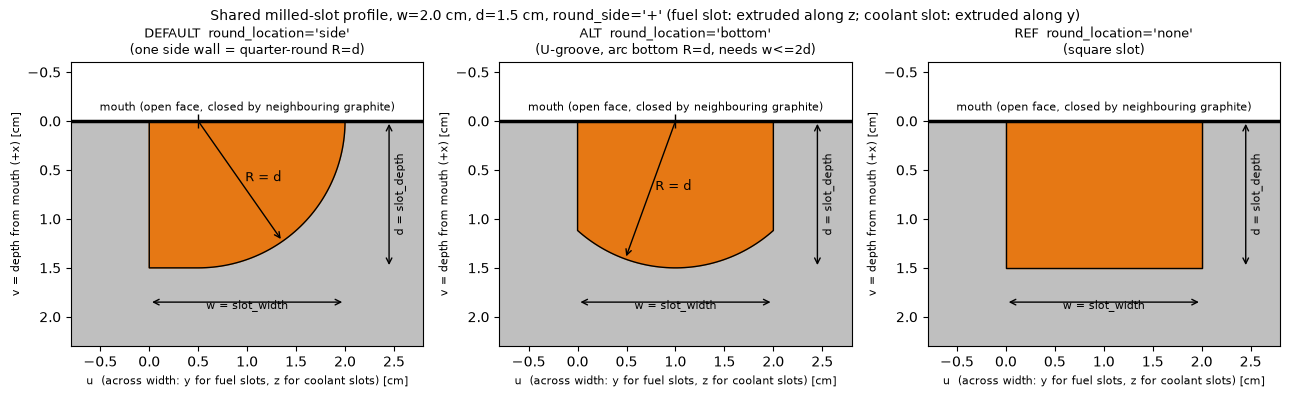

In [3]:
def sketch_profiles(w=2.0, d=1.5, round_side="+", filename=None):
    """Annotated cross-sections of the shared milled-slot profile for each round_location."""
    locs = [("side", "DEFAULT  round_location='side'\n(one side wall = quarter-round R=d)"),
            ("bottom", "ALT  round_location='bottom'\n(U-groove, arc bottom R=d, needs w<=2d)"),
            ("none", "REF  round_location='none'\n(square slot)")]
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, (loc, ttl) in zip(axs, locs):
        ok, msg = profile_feasible(w, d, loc)
        ax.add_patch(plt.Rectangle((-0.8, 0), w + 1.6, d + 0.8, color="0.75", zorder=0))
        if ok:
            o = profile_outline(w, d, loc, round_side)
            ax.fill(o[:, 0], o[:, 1], color="#e67814", zorder=1)
            ax.plot(o[:, 0], o[:, 1], "k", lw=1)
            if loc != "none":
                uc = (w - d if round_side == "+" else d) if loc == "side" else w / 2
                ax.plot([uc], [0], "k+", ms=10)
                ang = np.deg2rad(55) if round_side == "+" or loc == "bottom" else np.deg2rad(125)
                if loc == "bottom": ang = np.deg2rad(90 + 20)
                ax.annotate("", xy=(uc + d * np.cos(ang), d * np.sin(ang)), xytext=(uc, 0),
                            arrowprops=dict(arrowstyle="->"))
                ax.text(uc + 0.5 * d * np.cos(ang) + 0.05, 0.5 * d * np.sin(ang), "R = d", fontsize=9)
        else:
            ax.text(w / 2, d / 2, "infeasible:\n" + msg, ha="center", va="center", fontsize=8, wrap=True)
        ax.axhline(0, color="k", lw=2.5)
        ax.text(w / 2, -0.08, "mouth (open face, closed by neighbouring graphite)", ha="center", va="bottom", fontsize=8)
        ax.annotate("", xy=(0, d + 0.35), xytext=(w, d + 0.35), arrowprops=dict(arrowstyle="<->"))
        ax.text(w / 2, d + 0.42, "w = slot_width", ha="center", fontsize=8)
        ax.annotate("", xy=(w + 0.45, 0), xytext=(w + 0.45, d), arrowprops=dict(arrowstyle="<->"))
        ax.text(w + 0.5, d / 2, "d = slot_depth", rotation=90, va="center", fontsize=8)
        ax.set_xlim(-0.8, w + 0.8); ax.set_ylim(d + 0.8, -0.6); ax.set_aspect("equal")
        ax.set_xlabel("u  (across width: y for fuel slots, z for coolant slots) [cm]", fontsize=8)
        ax.set_ylabel("v = depth from mouth (+x) [cm]", fontsize=8)
        ax.set_title(ttl, fontsize=9)
    fig.suptitle(f"Shared milled-slot profile, w={w} cm, d={d} cm, round_side='{round_side}' "
                 "(fuel slot: extruded along z; coolant slot: extruded along y)", fontsize=10)
    fig.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig

fig = sketch_profiles(w=2.0, d=1.5, filename=os.path.join(WORK_DIR, "profile_sketch.png"))
plt.show()

## 2. Materials — default fuel = MSRE fuel salt (U-235 operation), per ORNL sources

| Quantity | Value used (default) | Source |
|---|---|---|
| Fuel salt composition | 7LiF-BeF₂-ZrF₄-UF₄ **65.0-29.17-5.0-0.83 mol%** | R. E. Thoma, *Chemical Aspects of MSRE Operations*, ORNL-4658 (1971), p. 10–11 (fuel for 235U operation; also Table 1.1: 65-29.2-5-0.83) |
| Uranium isotopics (start of power operation, run 4-1) | U-234 0.342, **U-235 33.477**, U-236 0.141, U-238 66.041 wt% | ORNL-4658 Table 2.8 |
| Li-7 in fuel carrier salt | **99.995 at%** (batch assays 99.994–99.996) | ORNL-4658 Table 2.11; same value used in the IRPhEP MSRE benchmark (Shen/Fratoni et al., PHYSOR 2020) |
| Fuel density | **ρ = 2.575 − 5.13×10⁻⁴·T(°C) g/cm³** (±1 %) → 2.242 g/cm³ at 649 °C (139.9 lb/ft³ at 650 °C) | ORNL-4658 Table 8.2 (Cantor molar-volume method; Table 8.3) |
| Coolant salt | 7LiF-BeF₂ 66-34 mol%, 99.992 % Li-7, ρ = 2.214 − 4.2×10⁻⁴·T(°C) → 1.941 g/cm³ at 649 °C | ORNL-4658 Tables 2.1, 8.1; ORNL-4616 |
| Graphite | 1.87 g/cm³ (MSRE grade CGB), pure C + `c_Graphite` | IRPhEP MSRE benchmark evaluation (1.87 ± 0.02 g/cm³) |

**Enrichment variable:** `ENRICHMENT` (top cell) = U-235 **weight %** of total uranium; also `build_model(..., enrichment=...)`,
`make_materials(enrichment=...)` and an optional 5th LHS dimension (`LHS_BOUNDS["enrichment"]`, off by default).
U-234/U-236 scale proportionally with enrichment (`minor_u="scale"`; exact MSRE isotopics at 33.477 wt%);
use `fuel={"minor_u": "none"}` for a pure U-235/U-238 vector.
The UF₄ mole fraction stays at 0.83 mol% when enrichment changes (so changing enrichment changes the U-235 loading).

**Alternatives found in ORNL sources (not used by default; switch via the `fuel=` dict):**
* Nominal design composition 65-29.1-5-0.9 mol% (ORNL-TM-728, Robertson 1965, Table 2.1; ORNL-4616; Haubenreich & Engel, *Nucl. Appl. Tech.* 8 (1970)); U "about 32 %" (ORNL-4616) / "33 %" (Haubenreich & Engel) enriched.
* Zero-power first-criticality salt 64.88-29.27-5.06-0.79 mol%, 1.408 wt% U-235 in salt, ρ = 2.3275 ± 0.016 g/cm³ at 638 °C (IRPhEP MSRE benchmark).
* Density: in-reactor inventory estimate 139.01 lb/ft³ (2.227 g/cm³) at start of power operation; electrical-probe correlation ρ = 2.848 − 7.69×10⁻⁴·T(°C) (2.35 g/cm³ at 650 °C); design value 141 lb/ft³ (2.26 g/cm³) (ORNL-4658 §8.2, Table 8.3).
* Li-7: "at least 99.99 %" (ORNL-4616), 99.994 % (ORNL-TM-728 Table 2.1).

In [4]:
# 2. Materials (MSRE fuel salt per ORNL sources - see the markdown cell above)
import re
def _formula(compound):
    return {el: int(n) if n else 1 for el, n in re.findall(r"([A-Z][a-z]?)(\d*)", compound)}

MSRE_U235_WT_PCT = 33.477      # U-235 wt% of total U at start of 235U power operation (ORNL-4658 Table 2.8, run 4-1)

DEFAULT_FUEL = dict(           # MSRE fuel salt, 235U operation (ORNL-4658, R.E. Thoma 1971)
    name="fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83)",
    composition_mol={"LiF": 65.0, "BeF2": 29.17, "ZrF4": 5.0, "UF4": 0.83},   # mol%  (ORNL-4658 p.10)
    density_a=2.575, density_b=5.13e-4,   # rho[g/cc] = a - b*T[degC]  (ORNL-4658 Table 8.2) -> 2.242 at 649 C
    density=None,                         # set a number (g/cc) to override the correlation
    u235_wt_pct=MSRE_U235_WT_PCT,         # ENRICHMENT = U-235 WEIGHT % of total uranium
    u234_wt_pct=0.342, u236_wt_pct=0.141, # ORNL-4658 Table 2.8 (run 4-1 nominal); U-238 = balance (66.041)
    minor_u="scale",                      # 'scale': U-234/U-236 scale with enrichment (exact MSRE values at 33.477)
                                          # 'fixed': use the wt% above as given;  'none': U-235 + U-238 only
    li7_at_pct=99.995,                    # 7Li assay of MSRE fuel carrier salt (ORNL-4658 Table 2.11: 99.994-99.996)
)
DEFAULT_COOLANT = dict(        # MSRE coolant/flush salt  7LiF-BeF2 66-34 mol%
    name="coolant salt (MSRE 7LiF-BeF2 66-34)",
    composition_mol={"LiF": 66.0, "BeF2": 34.0},
    density_a=2.214, density_b=4.2e-4,    # ORNL-4658 Table 8.1 (Li2BeF4) -> 1.941 g/cc at 649 C
    density=None,
    li7_at_pct=99.992,                    # ORNL-4658 Table 2.1 (coolant/flush batches 99.991-99.992)
)
DEFAULT_GRAPHITE = dict(name="graphite (MSRE CGB, 1.87 g/cc)", density=1.87, sab="c_Graphite")
# 1.87 +/- 0.02 g/cc: MSRE grade-CGB graphite density used in the IRPhEP MSRE benchmark evaluation (Fratoni et al.).
# Pure carbon (no boron impurity) - placeholder for Brian's actual graphite grade.

def salt_density(spec, temperature_K):
    if spec.get("density") is not None:
        return float(spec["density"])
    return spec["density_a"] - spec["density_b"] * (temperature_K - 273.15)

def uranium_wt_fractions(u235_wt_pct, u234_wt_pct=0.0, u236_wt_pct=0.0, minor_u="scale"):
    """Return {nuclide: wt fraction of U}.  `u235_wt_pct` = enrichment in WEIGHT percent."""
    e = float(u235_wt_pct)
    if not 0.0 < e <= 100.0:
        raise ValueError(f"enrichment (U-235 wt%) must be in (0, 100], got {e}")
    if minor_u == "scale":
        w234, w236 = u234_wt_pct * e / MSRE_U235_WT_PCT, u236_wt_pct * e / MSRE_U235_WT_PCT
    elif minor_u == "fixed":
        w234, w236 = u234_wt_pct, u236_wt_pct
    elif minor_u == "none":
        w234 = w236 = 0.0
    else:
        raise ValueError("minor_u must be 'scale', 'fixed' or 'none'")
    w238 = 100.0 - e - w234 - w236
    if w238 < -1e-9:
        raise ValueError(f"U-234 + U-235 + U-236 exceed 100 wt% (enrichment {e}); use minor_u='none'")
    w = {"U234": w234, "U235": e, "U236": w236, "U238": max(w238, 0.0)}
    return {k: v / 100.0 for k, v in w.items() if v > 0}

_AMU = {"U234": 234.0409521, "U235": 235.0439299, "U236": 236.0455680, "U238": 238.0507882}

def make_salt(spec, temperature=922.0):
    """openmc.Material from mol% of compounds, isotopics and a density correlation."""
    atoms = {}
    tot = sum(spec["composition_mol"].values())
    for comp, x in spec["composition_mol"].items():
        for el, n in _formula(comp).items():
            atoms[el] = atoms.get(el, 0.0) + n * x / tot
    mat = openmc.Material(name=spec["name"], temperature=temperature)
    for el, a in atoms.items():
        if el == "Li":
            f7 = spec.get("li7_at_pct", 99.995) / 100.0
            mat.add_nuclide("Li7", a * f7); mat.add_nuclide("Li6", a * (1 - f7))
        elif el == "U":
            wf = uranium_wt_fractions(spec["u235_wt_pct"], spec.get("u234_wt_pct", 0.0),
                                      spec.get("u236_wt_pct", 0.0), spec.get("minor_u", "scale"))
            moles = {k: v / _AMU[k] for k, v in wf.items()}                 # wt -> atom fractions
            s = sum(moles.values())
            for k, m in moles.items():
                mat.add_nuclide(k, a * m / s)
        elif el in ("Be", "F", "Na"):                                     # mono-isotopic
            mat.add_nuclide({"Be": "Be9", "F": "F19", "Na": "Na23"}[el], a)
        else:
            mat.add_element(el, a)
    mat.set_density("g/cm3", salt_density(spec, temperature))
    return mat

def make_materials(fuel=None, coolant=None, graphite=None, temperature=922.0, enrichment=None):
    """enrichment: U-235 wt% of uranium (None -> MSRE value, 33.477 wt%)."""
    fuel = {**DEFAULT_FUEL, **(fuel or {})}
    if enrichment is not None:
        fuel["u235_wt_pct"] = float(enrichment)
    coolant = {**DEFAULT_COOLANT, **(coolant or {})}
    graphite = {**DEFAULT_GRAPHITE, **(graphite or {})}
    m_fuel = make_salt(fuel, temperature); m_fuel.depletable = True
    m_cool = make_salt(coolant, temperature)
    m_gr = openmc.Material(name=graphite["name"], temperature=temperature)
    m_gr.add_element("C", 1.0)
    m_gr.set_density("g/cm3", graphite["density"])
    if graphite.get("sab"):
        m_gr.add_s_alpha_beta(graphite["sab"])
    return {"fuel": m_fuel, "coolant": m_cool, "graphite": m_gr}

_m = make_materials(temperature=TEMPERATURE_K, enrichment=ENRICHMENT)
for k, m in _m.items():
    print(f"{k:9s} {m.name:55s} {m.density:.4f} g/cc @ {m.temperature:.0f} K  nuclides: {', '.join(n.name for n in m.nuclides)}")
print("uranium vector (wt% of U):", {k: round(100 * v, 3) for k, v in uranium_wt_fractions(
      ENRICHMENT, DEFAULT_FUEL["u234_wt_pct"], DEFAULT_FUEL["u236_wt_pct"], DEFAULT_FUEL["minor_u"]).items()})
print(f"U-235 mass fraction in fuel salt: {100 * _m['fuel'].get_mass_density('U235') / _m['fuel'].density:.3f} wt%")

fuel      fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83) 2.2421 g/cc @ 922 K  nuclides: Li7, Li6, F19, Be9, Zr90, Zr91, Zr92, Zr94, Zr96, U234, U235, U236, U238
coolant   coolant salt (MSRE 7LiF-BeF2 66-34)                     1.9415 g/cc @ 922 K  nuclides: Li7, Li6, F19, Be9
graphite  graphite (MSRE CGB, 1.87 g/cc)                          1.8700 g/cc @ 922 K  nuclides: C12, C13
uranium vector (wt% of U): {'U234': 0.342, 'U235': 33.477, 'U236': 0.141, 'U238': 66.04}
U-235 mass fraction in fuel salt: 1.584 wt%


## 3. Parameter validation, layer stack and analytic volume fractions
`resolve_params()` validates the inputs (positive, `w ≥ d` for the one-side radius, …) and returns the x-layer stack;
`analytic_metrics()` gives exact volume fractions / moderator-to-fuel ratio for the periodic cell (no transport needed).

In [5]:
# 3. Layer stack / unit-cell dimensions (pure python - no OpenMC objects)
def resolve_params(slot_width=2.0, slot_depth=1.5, web_thickness=1.5, wall_thickness=2.0, *,
                   n_slot_pairs=2, round_location="side",
                   fuel_round_side="+", coolant_round_side="+", inplane_web=None, **_ignored):
    """Validate the parameters and return the unit-cell layout.

    Layers are stacked along x (slab-thickness / stacking direction).  Each entry of
    `layers` is (kind, thickness) with kind in {'F','C','web','wall'}.
    'F' layer = fuel-slot row (thickness = slot_depth); its slots run along z, width along y.
    'C' layer = coolant-slot row (thickness = slot_depth); its slots run along y, width along z.
    """
    w, d, t_web, t_wall = map(float, (slot_width, slot_depth, web_thickness, wall_thickness))
    errs = []
    for k, v in dict(slot_width=w, slot_depth=d, web_thickness=t_web, wall_thickness=t_wall).items():
        if not (v > 0 and math.isfinite(v)):
            errs.append(f"{k} must be a positive finite number (got {v})")
    if int(n_slot_pairs) != n_slot_pairs or n_slot_pairs < 1:
        errs.append("n_slot_pairs must be an integer >= 1")
    for s in (fuel_round_side, coolant_round_side):
        if s not in "+-" or len(s) != 1:
            errs.append("round sides must be '+' or '-'")
    if not errs:
        ok, msg = profile_feasible(w, d, round_location)
        if not ok:
            errs.append(msg)
    web_ip = t_web if inplane_web is None else float(inplane_web)
    if web_ip <= 0:
        errs.append("inplane_web must be > 0")
    if errs:
        raise ValueError("; ".join(errs))

    # one slab = F web C [web F web C]*(n-1); neighbouring slabs separated by ONE wall
    layers = [("F", d), ("web", t_web), ("C", d)]
    for _ in range(int(n_slot_pairs) - 1):
        layers += [("web", t_web), ("F", d), ("web", t_web), ("C", d)]
    layers += [("wall", t_wall)]
    return dict(slot_width=w, slot_depth=d, web_thickness=t_web, wall_thickness=t_wall,
                n_slot_pairs=int(n_slot_pairs), round_location=round_location,
                fuel_round_side=fuel_round_side, coolant_round_side=coolant_round_side,
                inplane_web=web_ip, layers=layers,
                pitch_x=sum(t for _, t in layers), pitch_y=w + web_ip, pitch_z=w + web_ip)

def is_feasible(**kw):
    try:
        resolve_params(**kw); return True, ""
    except ValueError as e:
        return False, str(e)

def analytic_metrics(core_radius=None, **kw):
    """Volume fractions etc. of the infinite periodic unit cell (exact, no transport).
    If core_radius is given, also the (approximate: fraction x volume) salt volumes in the H=2R cylinder."""
    p = resolve_params(**kw)
    w, d, loc = p["slot_width"], p["slot_depth"], p["round_location"]
    A, Pm = profile_area(w, d, loc), profile_perimeter(w, d, loc)
    nF = sum(k == "F" for k, _ in p["layers"]); nC = sum(k == "C" for k, _ in p["layers"])
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]
    V = Px * Py * Pz
    Vf = nF * A * Pz            # fuel slots run along z
    Vc = nC * A * Py            # coolant slots run along y
    Vg = V - Vf - Vc
    return dict(pitch_x=Px, pitch_y=Py, pitch_z=Pz, slot_area=A, slot_perimeter=Pm,
                fuel_vf=Vf / V, coolant_vf=Vc / V, graphite_vf=Vg / V,
                graphite_to_fuel=Vg / Vf, coolant_to_fuel=Vc / Vf,
                fuel_hydraulic_diam=4 * A / Pm,
                fuel_wetted_area_per_fuel_vol=Pm / A,      # cm^2 / cm^3 (same for coolant)
                slab_thickness=Px - p["wall_thickness"],
                **({} if core_radius is None else dict(
                    core_volume_l=2 * math.pi * core_radius**3 / 1000.0,
                    core_fuel_volume_l=Vf / V * 2 * math.pi * core_radius**3 / 1000.0,
                    core_coolant_volume_l=Vc / V * 2 * math.pi * core_radius**3 / 1000.0)))

pd.Series(analytic_metrics()).to_frame("default geometry")

,default geometry
pitch_x,12.500000
pitch_y,3.500000
pitch_z,3.500000
slot_area,2.517146
slot_perimeter,6.356194
fuel_vf,0.115070
coolant_vf,0.115070
graphite_vf,0.769861
graphite_to_fuel,6.690398
coolant_to_fuel,1.000000


## 4. OpenMC geometry: `build_model(...) -> openmc.Model`

In [6]:
# 4. OpenMC geometry
def build_unit_universe(p, mats):
    """Universe of one unit cell, centred on the origin, with UNBOUNDED cells so it can be
    used both as a periodic unit cell and as a lattice element."""
    w, d, loc = p["slot_width"], p["slot_depth"], p["round_location"]
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]
    web_ip = p["inplane_web"]
    x = -Px / 2.0
    cells, slots = [], []
    for i, (kind, t) in enumerate(p["layers"]):
        if kind == "F":
            # vertical fuel slot: runs along z, width along y, mouth at the layer's -x face
            r = milled_slot_region("z", "x", "y", mouth=x, u0=-Py / 2 + web_ip / 2, w=w, d=d,
                                   round_location=loc, round_side=p["fuel_round_side"])
            c = openmc.Cell(name=f"fuel slot (layer {i})", fill=mats["fuel"], region=r)
        elif kind == "C":
            # horizontal coolant slot: runs along y, width along z, mouth at the layer's -x face
            r = milled_slot_region("y", "x", "z", mouth=x, u0=-Pz / 2 + web_ip / 2, w=w, d=d,
                                   round_location=loc, round_side=p["coolant_round_side"])
            c = openmc.Cell(name=f"coolant slot (layer {i})", fill=mats["coolant"], region=r)
        else:
            c = None
        if c is not None:
            cells.append(c); slots.append(r)
        x += t
    gr_region = ~openmc.Union(slots)
    cells.append(openmc.Cell(name="graphite (webs + walls)", fill=mats["graphite"], region=gr_region))
    return openmc.Universe(name="slab unit cell", cells=cells)

def _box(Lx, Ly, Lz, bc="transmission", center=(0, 0, 0)):
    cx, cy, cz = center
    s = [openmc.XPlane(cx - Lx / 2, boundary_type=bc), openmc.XPlane(cx + Lx / 2, boundary_type=bc),
         openmc.YPlane(cy - Ly / 2, boundary_type=bc), openmc.YPlane(cy + Ly / 2, boundary_type=bc),
         openmc.ZPlane(cz - Lz / 2, boundary_type=bc), openmc.ZPlane(cz + Lz / 2, boundary_type=bc)]
    return s, (+s[0] & -s[1] & +s[2] & -s[3] & +s[4] & -s[5])

def build_model(slot_width=2.0, slot_depth=1.5, web_thickness=1.5, wall_thickness=2.0, *,
                n_slot_pairs=2, round_location="side",
                fuel_round_side="+", coolant_round_side="+", inplane_web=None,
                mode="cylinder", core_radius=70.0, reflector_thickness=0.0,
                enrichment=None, fuel=None, coolant=None, graphite=None, temperature=922.0,
                particles=10000, batches=100, inactive=30, seed=1):
    """Return an openmc.Model of the slotted-graphite-slab core.

    mode="cylinder"  : (default) the slab stack (RectLattice of unit cells) fills a right cylinder of radius
                       R = core_radius and height H = 2R (z in [-R, R]); optional graphite reflector of
                       `reflector_thickness` on the side, top and bottom; vacuum outside  -> finite k-eff.
    mode="unit_cell" : one unit cell with PERIODIC boundaries on all six faces -> k-infinity (quick mode).
    enrichment       : U-235 wt% of total uranium in the fuel salt (None -> MSRE 33.477 wt%).
    """
    p = resolve_params(slot_width, slot_depth, web_thickness, wall_thickness,
                       n_slot_pairs=n_slot_pairs, round_location=round_location,
                       fuel_round_side=fuel_round_side, coolant_round_side=coolant_round_side,
                       inplane_web=inplane_web)
    if mode not in ("cylinder", "unit_cell"):
        raise ValueError("mode must be 'cylinder' or 'unit_cell'")
    mats = make_materials(fuel, coolant, graphite, temperature, enrichment)
    univ = build_unit_universe(p, mats)
    Px, Py, Pz = p["pitch_x"], p["pitch_y"], p["pitch_z"]

    if mode == "unit_cell":
        s, region = _box(Px, Py, Pz, bc="periodic")
        s[0].periodic_surface = s[1]; s[2].periodic_surface = s[3]; s[4].periodic_surface = s[5]
        root = openmc.Universe(cells=[openmc.Cell(name="unit cell", fill=univ, region=region)])
        source = openmc.IndependentSource(space=openmc.stats.Box((-Px / 2, -Py / 2, -Pz / 2), (Px / 2, Py / 2, Pz / 2)),
                                          constraints={"fissionable": True})
    else:
        R, t = float(core_radius), float(reflector_thickness)
        if not R > 0 or t < 0:
            raise ValueError("core_radius must be > 0 and reflector_thickness >= 0")
        if R < 2 * max(Px, Py, Pz):
            raise ValueError(f"core_radius {R} too small for the unit-cell pitch ({Px:.2f} x {Py:.2f} x {Pz:.2f} cm)")
        # lattice just large enough to cover the cylinder; an odd count centres a unit cell on the axis
        n = [2 * int(math.ceil(R / P - 0.5)) + 1 for P in (Px, Py, Pz)]
        lat = openmc.RectLattice(name="slab stack")
        lat.pitch = (Px, Py, Pz)
        lat.lower_left = (-n[0] * Px / 2, -n[1] * Py / 2, -n[2] * Pz / 2)
        lat.universes = np.full((n[2], n[1], n[0]), univ)          # [z][y][x]
        lat.outer = openmc.Universe(cells=[openmc.Cell(fill=mats["graphite"])])
        cyl = openmc.ZCylinder(r=R); zlo = openmc.ZPlane(-R); zhi = openmc.ZPlane(R)
        core = -cyl & +zlo & -zhi
        cells = [openmc.Cell(name="slab-stack core", fill=lat, region=core)]
        if t > 0:
            cyl_o = openmc.ZCylinder(r=R + t, boundary_type="vacuum")
            zlo_o = openmc.ZPlane(-R - t, boundary_type="vacuum"); zhi_o = openmc.ZPlane(R + t, boundary_type="vacuum")
            cells.append(openmc.Cell(name="graphite reflector", fill=mats["graphite"],
                                     region=-cyl_o & +zlo_o & -zhi_o & ~core))
        else:
            for srf in (cyl, zlo, zhi):
                srf.boundary_type = "vacuum"
        root = openmc.Universe(cells=cells)
        p.update(core_radius=R, core_height=2 * R, reflector_thickness=t, lattice_shape=tuple(n))
        source = openmc.IndependentSource(
            space=openmc.stats.CylindricalIndependent(r=openmc.stats.PowerLaw(0.0, R, 1.0),
                                                      phi=openmc.stats.Uniform(0.0, 2 * math.pi),
                                                      z=openmc.stats.Uniform(-R, R)),
            constraints={"fissionable": True})

    geometry = openmc.Geometry(root)
    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles, settings.batches, settings.inactive = int(particles), int(batches), int(inactive)
    settings.seed = int(seed)
    settings.temperature = {"method": "nearest", "tolerance": 150.0, "default": temperature}
    settings.source = source
    settings.output = {"tallies": False}
    model = openmc.Model(geometry=geometry, materials=openmc.Materials(mats.values()), settings=settings)
    model.params = {**p, "mode": mode}   # handy for bookkeeping
    model.mats = mats
    return model

In [7]:
# ---- default geometry (cm) ----
DEFAULTS = dict(slot_width=2.0, slot_depth=1.5, web_thickness=1.5, wall_thickness=2.0)
GEOM_OPTS = dict(n_slot_pairs=2, round_location="side", fuel_round_side="+", coolant_round_side="+")
RUN_OPTS = dict(particles=PARTICLES, batches=BATCHES, inactive=INACTIVE, temperature=TEMPERATURE_K)

GEOM_OPTS_CORE = dict(GEOM_OPTS, mode=MODE, reflector_thickness=REFLECTOR_THICKNESS)
model = build_model(**DEFAULTS, **GEOM_OPTS_CORE, core_radius=CORE_RADIUS, enrichment=ENRICHMENT, **RUN_OPTS)   # finite core
model_uc = build_model(**DEFAULTS, **GEOM_OPTS, mode="unit_cell", enrichment=ENRICHMENT, **RUN_OPTS)            # k-inf cell
p = model_uc.params
print("layers along x:", p["layers"])
print(f"unit cell pitch  Px={p['pitch_x']:.3f}  Py={p['pitch_y']:.3f}  Pz={p['pitch_z']:.3f} cm")
if MODE == "cylinder":
    print(f"core: R = {CORE_RADIUS} cm, H = {2*CORE_RADIUS} cm, reflector = {REFLECTOR_THICKNESS} cm, "
          f"lattice {model.params['lattice_shape']} (x, y, z) unit cells")
    print({k: round(v, 1) for k, v in analytic_metrics(**DEFAULTS, **GEOM_OPTS, core_radius=CORE_RADIUS).items() if k.startswith("core_")})
for c in model_uc.geometry.get_all_cells().values():
    print(f"  cell {c.id:3d} {c.name:28s} fill={c.fill.name if hasattr(c.fill,'name') else c.fill}")
os.makedirs(os.path.join(WORK_DIR, "baseline"), exist_ok=True)
model.export_to_model_xml(os.path.join(WORK_DIR, "baseline", "model.xml"))
os.makedirs(os.path.join(WORK_DIR, "baseline_kinf"), exist_ok=True)
model_uc.export_to_model_xml(os.path.join(WORK_DIR, "baseline_kinf", "model.xml"))

layers along x: [('F', 1.5), ('web', 1.5), ('C', 1.5), ('web', 1.5), ('F', 1.5), ('web', 1.5), ('C', 1.5), ('wall', 2.0)]
unit cell pitch  Px=12.500  Py=3.500  Pz=3.500 cm
core: R = 70.0 cm, H = 140.0 cm, reflector = 0.0 cm, lattice (13, 41, 41) (x, y, z) unit cells
{'core_volume_l': 2155.1, 'core_fuel_volume_l': 248.0, 'core_coolant_volume_l': 248.0}
  cell  13 unit cell                    fill=slab unit cell
  cell   8 fuel slot (layer 0)          fill=fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83)
  cell   9 coolant slot (layer 2)       fill=coolant salt (MSRE 7LiF-BeF2 66-34)
  cell  10 fuel slot (layer 4)          fill=fuel salt (MSRE 7LiF-BeF2-ZrF4-UF4 65.0-29.17-5.0-0.83)
  cell  11 coolant slot (layer 6)       fill=coolant salt (MSRE 7LiF-BeF2 66-34)
  cell  12 graphite (webs + walls)      fill=graphite (MSRE CGB, 1.87 g/cc)


## 5. Geometry plots (coloured by material)
OpenMC's plotter needs a `cross_sections.xml`; without one the helper falls back to a pure-Python renderer
(`geometry.find()` per pixel), so plots always work. Full-core xy/xz slices of the cylinder, then close-ups of the slot pattern at the core centre.

In [8]:
MAT_COLORS = {"fuel": (230, 120, 20), "coolant": (40, 110, 220), "graphite": (150, 150, 150)}

def have_cross_sections():
    xs = openmc.config.get("cross_sections")
    return xs is not None and os.path.exists(str(xs))

def _color_map(model):
    return {model.mats[k]: MAT_COLORS[k] for k in model.mats}

def plot_slice_python(model, basis="xy", origin=(0, 0, 0), width=(10, 10), pixels=(300, 300), ax=None):
    """Nuclear-data-free fallback: colour each pixel by geometry.find() (pure-Python CSG)."""
    ax = ax or plt.subplots(figsize=(7, 7 * width[1] / width[0]))[1]
    i, j = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}[basis]
    nx, ny = pixels
    cmap = {m.id: np.array(c) / 255 for m, c in _color_map(model).items()}
    img = np.ones((ny, nx, 3))
    us = origin[i] - width[0] / 2 + (np.arange(nx) + 0.5) * width[0] / nx
    vs = origin[j] + width[1] / 2 - (np.arange(ny) + 0.5) * width[1] / ny
    for r, v in enumerate(vs):
        for c, u in enumerate(us):
            pt = list(origin); pt[i] = u; pt[j] = v
            path = model.geometry.find(pt)
            if path and isinstance(path[-1], openmc.Cell) and isinstance(path[-1].fill, openmc.Material):
                img[r, c] = cmap[path[-1].fill.id]
    ext = [origin[i] - width[0] / 2, origin[i] + width[0] / 2, origin[j] - width[1] / 2, origin[j] + width[1] / 2]
    ax.imshow(img, extent=ext, origin="upper", interpolation="nearest")
    ax.set_xlabel(f"{basis[0]} [cm]"); ax.set_ylabel(f"{basis[1]} [cm]")
    return ax

def plot_slice(model, basis="xy", origin=(0, 0, 0), width=(10, 10), pixels=(600, 600),
               title=None, filename=None, force_python=False):
    """Slice plot coloured by material. Uses openmc's plotter (needs cross_sections.xml);
    falls back to pure-Python point sampling if nuclear data are not configured."""
    aspect = width[1] / width[0]
    fig, ax = plt.subplots(figsize=(9, max(3.2, 9 * aspect) + 1.2))
    used = "openmc"
    if have_cross_sections() and not force_python:
        try:
            model.plot(basis=basis, origin=origin, width=width, pixels=pixels, color_by="material",
                       colors=_color_map(model), axes=ax)
        except Exception as e:                        # pragma: no cover
            warnings.warn(f"openmc plot failed ({e}); using python fallback"); used = "python"
    else:
        used = "python"
    if used == "python":
        px = (min(pixels[0], 400), max(1, int(min(pixels[0], 400) * width[1] / width[0])))
        plot_slice_python(model, basis, origin, width, px, ax=ax)
    ax.set_xlabel(f"{basis[0]} [cm]"); ax.set_ylabel(f"{basis[1]} [cm]")
    ax.legend(handles=[Patch(color=np.array(c) / 255, label=model.mats[k].name) for k, c in MAT_COLORS.items()],
              loc="upper center", bbox_to_anchor=(0.5, -0.1 if aspect < 0.8 else -0.07), ncol=2, fontsize=8, frameon=False)
    ax.set_title("\n".join(textwrap.wrap((title or f"{basis} slice at {tuple(round(o, 3) for o in origin)}")
                                         + f"  [{used} renderer]", 90)), fontsize=9)
    fig.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150)
    return fig, ax

def csg_volume_check(model, n=20000, seed=0):
    """Monte-Carlo point sampling of the (periodic unit-cell) model with pure-Python
    geometry.find(); returns sampled volume fractions of fuel / coolant / graphite."""
    rng = np.random.default_rng(seed)
    p = model.params
    L = np.array([p["pitch_x"], p["pitch_y"], p["pitch_z"]])
    pts = (rng.random((n, 3)) - 0.5) * L
    ids = {m.id: k for k, m in model.mats.items()}
    counts = dict.fromkeys(model.mats, 0)
    for pt in pts:
        cell = model.geometry.find(pt)[-1]
        counts[ids[cell.fill.id]] += 1
    return {f"{k}_vf": (c / n, math.sqrt(c / n * (1 - c / n) / n)) for k, c in counts.items()}

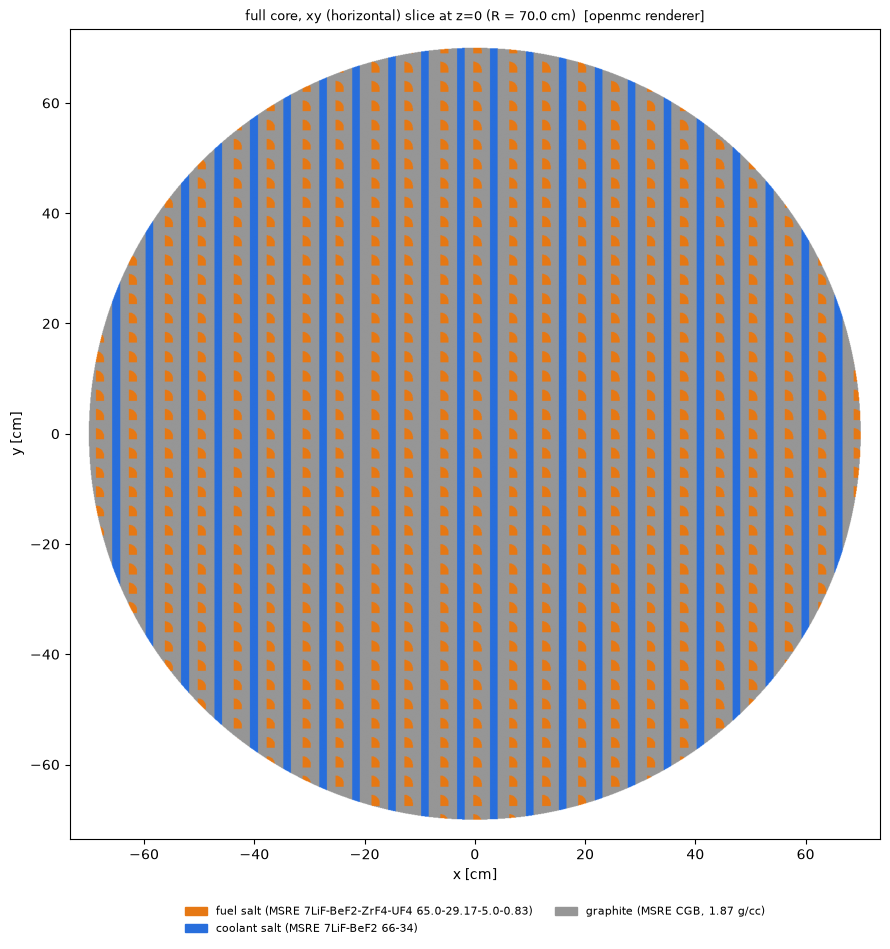

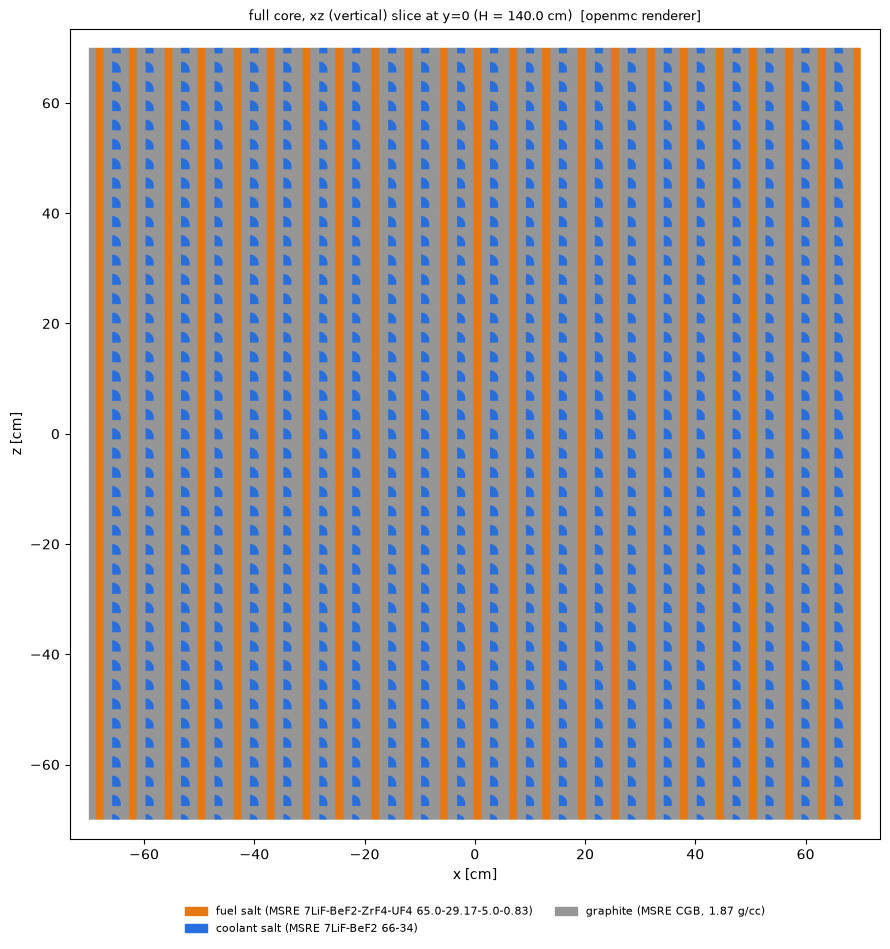

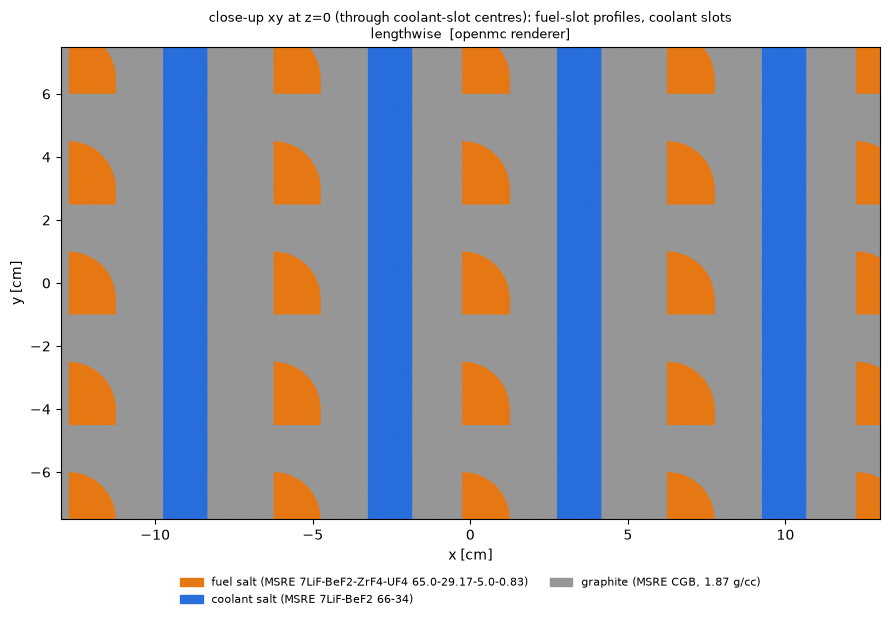

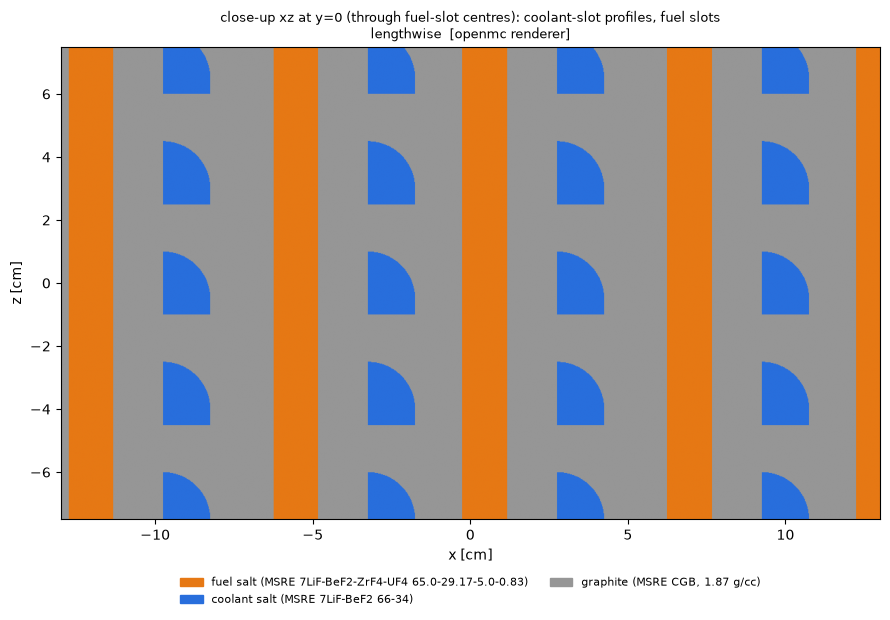

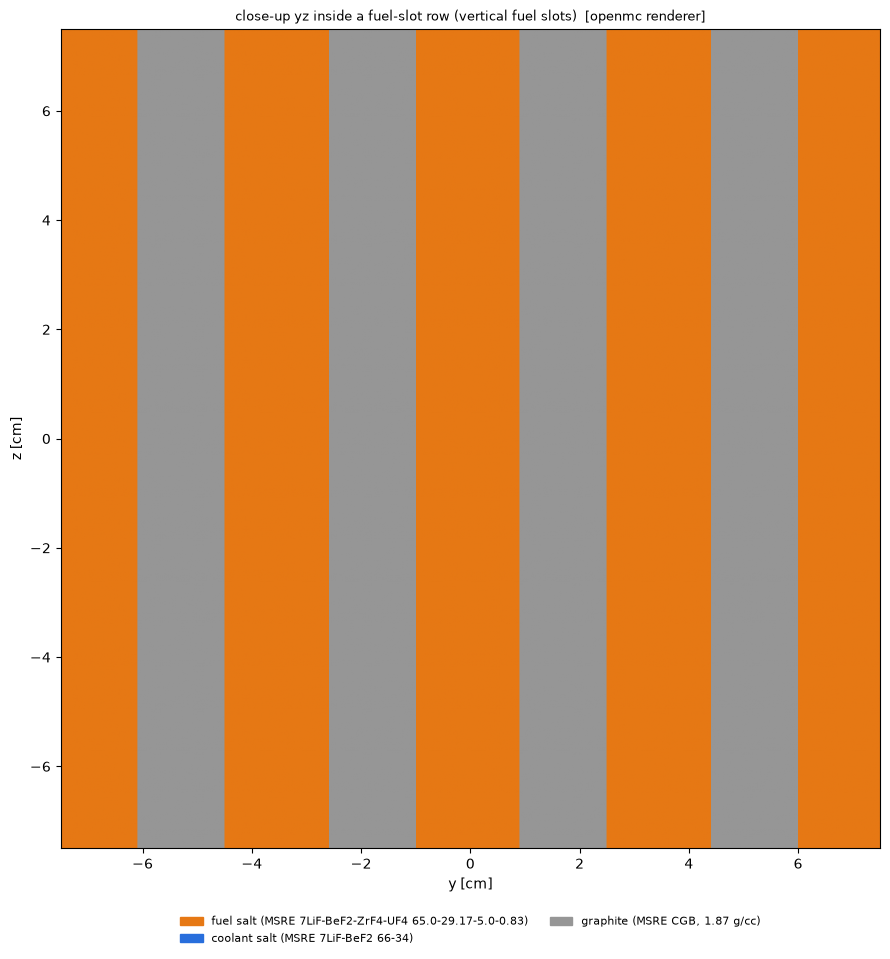

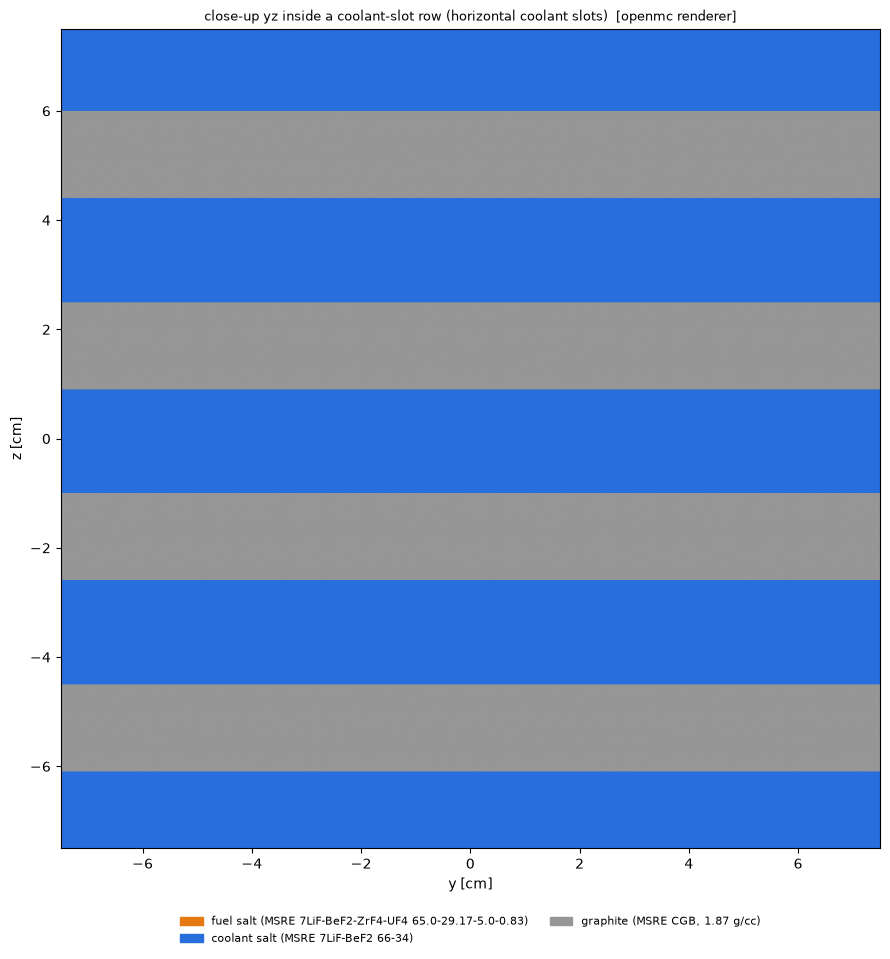

In [9]:
R_ = CORE_RADIUS + REFLECTOR_THICKNESS
Px, Py, Pz, d, tw = p["pitch_x"], p["pitch_y"], p["pitch_z"], p["slot_depth"], p["web_thickness"]
# full core
plot_slice(model, "xy", origin=(0, 0, 0), width=(2.1 * R_, 2.1 * R_), pixels=(1600, 1600),
           title=f"full core, xy (horizontal) slice at z=0 (R = {CORE_RADIUS} cm)", filename=os.path.join(WORK_DIR, "geom_core_xy.png"))
plot_slice(model, "xz", origin=(0, 0, 0), width=(2.1 * R_, 2.1 * R_), pixels=(1600, 1600),
           title=f"full core, xz (vertical) slice at y=0 (H = {2*CORE_RADIUS} cm)", filename=os.path.join(WORK_DIR, "geom_core_xz.png"))
# close-ups of the slot pattern at the core centre (a unit cell is centred on the axis)
W = (2 * Px + 1, 4 * Py + 1, 4 * Pz + 1)
x_fuel = -Px / 2 + 0.35 * d                  # inside the first fuel-slot row of the central unit cell
x_cool = -Px / 2 + d + tw + 0.35 * d         # inside the first coolant-slot row
plot_slice(model, "xy", origin=(0, 0, 0), width=(W[0], W[1]), pixels=(1200, int(1200 * W[1] / W[0])),
           title="close-up xy at z=0 (through coolant-slot centres): fuel-slot profiles, coolant slots lengthwise",
           filename=os.path.join(WORK_DIR, "geom_xy.png"))
plot_slice(model, "xz", origin=(0, 0, 0), width=(W[0], W[2]), pixels=(1200, int(1200 * W[2] / W[0])),
           title="close-up xz at y=0 (through fuel-slot centres): coolant-slot profiles, fuel slots lengthwise",
           filename=os.path.join(WORK_DIR, "geom_xz.png"))
plot_slice(model, "yz", origin=(x_fuel, 0, 0), width=(W[1], W[2]), pixels=(800, 800),
           title="close-up yz inside a fuel-slot row (vertical fuel slots)", filename=os.path.join(WORK_DIR, "geom_yz_fuel_row.png"))
plot_slice(model, "yz", origin=(x_cool, 0, 0), width=(W[1], W[2]), pixels=(800, 800),
           title="close-up yz inside a coolant-slot row (horizontal coolant slots)", filename=os.path.join(WORK_DIR, "geom_yz_coolant_row.png"))
plt.show()

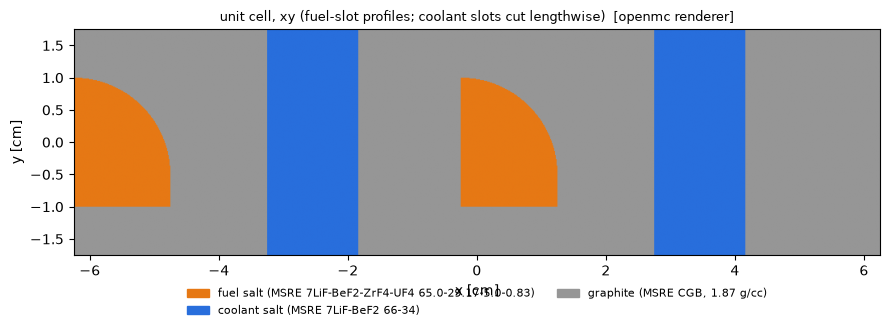

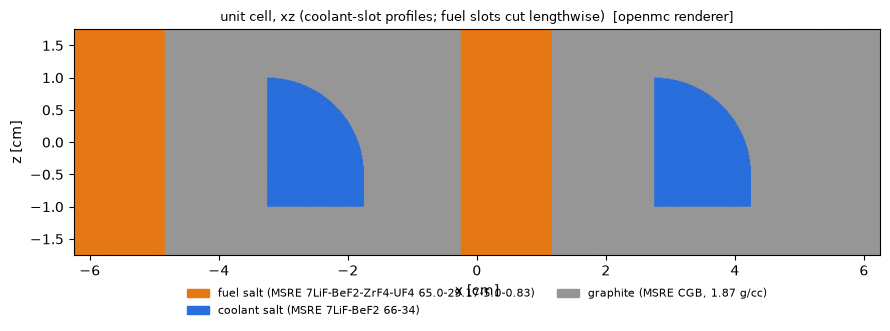

In [10]:
# zoom on ONE periodic unit cell (the k-inf model): profiles of both slot types
plot_slice(model_uc, "xy", origin=(0, 0, 0), width=(p["pitch_x"], p["pitch_y"]), pixels=(1000, int(1000 * p["pitch_y"] / p["pitch_x"])),
           title="unit cell, xy (fuel-slot profiles; coolant slots cut lengthwise)", filename=os.path.join(WORK_DIR, "geom_unitcell_xy.png"))
plot_slice(model_uc, "xz", origin=(0, 0, 0), width=(p["pitch_x"], p["pitch_z"]), pixels=(1000, int(1000 * p["pitch_z"] / p["pitch_x"])),
           title="unit cell, xz (coolant-slot profiles; fuel slots cut lengthwise)", filename=os.path.join(WORK_DIR, "geom_unitcell_xz.png"))
plt.show()

## 6. Check: CSG volumes (Monte-Carlo point sampling of the OpenMC geometry) vs. closed-form formulas
Pure Python, no nuclear data needed. Agreement within ~2σ confirms the CSG matches the intended profile.

In [11]:
rows = []
for loc, w in [("side", 2.0), ("bottom", 2.0), ("none", 2.0), ("side", 1.5)]:
    kw = dict(DEFAULTS, slot_width=w, round_location=loc)
    m = build_model(**kw, mode="unit_cell")
    mc = csg_volume_check(m, n=20000, seed=1)
    an = analytic_metrics(**kw)
    for k in ("fuel_vf", "coolant_vf", "graphite_vf"):
        rows.append(dict(round_location=loc, slot_width=w, quantity=k, analytic=an[k], csg_mc=mc[k][0],
                         sigma=mc[k][1], n_sigma=(mc[k][0] - an[k]) / mc[k][1]))
chk = pd.DataFrame(rows)
display(chk.round(4))
assert (chk["n_sigma"].abs() < 4).all(), "CSG and analytic volume fractions disagree!"

,round_location,slot_width,quantity,analytic,csg_mc,sigma,n_sigma
0,side,2.0,fuel_vf,0.1151,0.1134,0.0022,-0.7222
1,side,2.0,coolant_vf,0.1151,0.1178,0.0023,1.2195
2,side,2.0,graphite_vf,0.7699,0.7687,0.0030,-0.3894
3,bottom,2.0,fuel_vf,0.1262,0.1240,0.0023,-0.9086
4,bottom,2.0,coolant_vf,0.1262,0.1291,0.0024,1.2576
5,bottom,2.0,graphite_vf,0.7477,0.7468,0.0031,-0.2811
6,none,2.0,fuel_vf,0.1371,0.1346,0.0024,-1.0537
7,none,2.0,coolant_vf,0.1371,0.1400,0.0025,1.1645
8,none,2.0,graphite_vf,0.7257,0.7254,0.0032,-0.0996
9,side,1.5,fuel_vf,0.0942,0.0920,0.0020,-1.1246


## 7. First model: finite-cylinder k-eff at the default parameters (+ quick unit-cell k-inf)

In [12]:
def run_and_report(m, subdir, label):
    t0 = time.time()
    sp_path = m.run(cwd=os.path.join(WORK_DIR, subdir), output=False, threads=THREADS)
    dt = time.time() - t0
    with openmc.StatePoint(sp_path) as sp:
        k = sp.keff
        n_act = sp.n_batches - sp.n_inactive
        gt = sp.global_tallies
        names = [n.decode() if isinstance(n, bytes) else str(n) for n in gt["name"]]
        leak = float(gt["mean"][names.index("leakage")]) if "leakage" in names else None
    res = dict(case=label, keff=k.nominal_value, keff_std=k.std_dev, keff_std_pcm=k.std_dev * 1e5,
               leakage_fraction=leak, particles=m.settings.particles, batches=m.settings.batches,
               inactive=m.settings.inactive, runtime_s=dt, library=str(openmc.config.get("cross_sections")),
               enrichment_u235_wt_pct=ENRICHMENT, temperature_K=TEMPERATURE_K, **DEFAULTS,
               **{k_: v for k_, v in m.params.items() if k_ in ("mode", "core_radius", "core_height", "reflector_thickness", "lattice_shape")})
    print(f"{label}: k = {res['keff']:.5f} +/- {res['keff_std']:.5f} ({res['keff_std_pcm']:.0f} pcm)"
          + (f", leakage = {leak:.4f}" if leak is not None else "")
          + f"  [{res['particles']} particles x {n_act} active / {res['batches']} batches, {dt:.0f} s]")
    return res

baseline = []
if HAVE_XS and RUN_KINF:
    baseline.append(run_and_report(model_uc, "baseline_kinf", "unit cell (periodic) k-inf"))
if HAVE_XS and RUN_BASELINE:
    baseline.append(run_and_report(model, "baseline", f"finite cylinder R={CORE_RADIUS} cm, H={2*CORE_RADIUS} cm k-eff"))
if baseline:
    bdf = pd.DataFrame(baseline)
    bdf.to_csv(os.path.join(WORK_DIR, "baseline_results.csv"), index=False)
    with open(os.path.join(WORK_DIR, "baseline_results.json"), "w") as fh:
        json.dump(baseline, fh, indent=1, default=str)
    display(bdf[["case", "keff", "keff_std_pcm", "leakage_fraction", "particles", "batches", "inactive", "runtime_s"]].round(5))
    if len(baseline) == 2:
        kinf, keff, L = baseline[0]["keff"], baseline[1]["keff"], baseline[1]["leakage_fraction"]
        print(f"k_eff / k_inf = {keff / kinf:.3f}   (1 - leakage = {1 - L:.3f}); "
              f"the bare R = {CORE_RADIUS} cm core is {'sub' if keff < 1 else 'super'}critical by {abs(keff - 1) * 1e5:.0f} pcm")
else:
    print("baseline transport skipped (HAVE_XS =", HAVE_XS, ")")

unit cell (periodic) k-inf: k = 1.63091 +/- 0.00107 (107 pcm), leakage = 0.0000  [10000 particles x 60 active / 100 batches, 120 s]


finite cylinder R=70.0 cm, H=140.0 cm k-eff: k = 0.81888 +/- 0.00136 (136 pcm), leakage = 0.4805  [10000 particles x 60 active / 100 batches, 78 s]


,case,keff,keff_std_pcm,leakage_fraction,particles,batches,inactive,runtime_s
0,unit cell (periodic) k-inf,1.63091,106.93975,0.00000,10000,100,40,120.37561
1,"finite cylinder R=70.0 cm, H=140.0 cm k-eff",0.81888,135.67637,0.48048,10000,100,40,78.12315


k_eff / k_inf = 0.502   (1 - leakage = 0.520); the bare R = 70.0 cm core is subcritical by 18112 pcm


## 8. Latin-hypercube sampling of the four geometry parameters
* `LHS_BOUNDS` — (low, high) in cm for each free parameter; `FIXED` — hold any parameter constant (it is removed from the hypercube).
* Samples violating geometric feasibility (e.g. `slot_width < slot_depth` for the one-side radius) are **filtered** and reported.
* Each feasible sample gets its own directory `lhs_runs/sample_XXX/` with `model.xml` + `params.json` (+ statepoint if run).

In [13]:
PARAM_NAMES = ("slot_width", "slot_depth", "web_thickness", "wall_thickness")   # geometry (cm)
OPTIONAL_PARAMS = ("enrichment", "core_radius")   # U-235 wt% of U, cylinder radius R (cm): sampled only if in bounds
ALL_PARAMS = PARAM_NAMES + OPTIONAL_PARAMS

def lhs_samples(bounds, n_samples, seed=None, fixed=None, geometry_opts=None, defaults=None, optimization=None):
    """Latin-hypercube samples.

    bounds   : {name: (low, high)} for every parameter to vary. The four geometry parameters must each be
               in `bounds` or `fixed`; 'enrichment' (U-235 wt%) and 'core_radius' (cm, H = 2R) are varied only
               if they appear in `bounds`, otherwise they take fixed[...] or defaults[...].
    fixed    : {name: value} parameters held constant (excluded from the hypercube)
    Returns a DataFrame with a 'feasible' flag and the reason for infeasible rows.
    """
    fixed = dict(fixed or {}); geometry_opts = dict(geometry_opts or {})
    defaults = {"enrichment": None, "core_radius": 70.0, **(defaults or {})}
    unknown = (set(bounds) | set(fixed)) - set(ALL_PARAMS)
    if unknown:
        raise ValueError(f"unknown parameter(s): {unknown}; allowed: {ALL_PARAMS}")
    free = [k for k in ALL_PARAMS if k in bounds and k not in fixed]
    missing = [k for k in PARAM_NAMES if k not in bounds and k not in fixed]
    if missing:
        raise ValueError(f"need bounds (or a fixed value) for {missing}")
    for k in free:
        lo, hi = bounds[k]
        if not (0 < lo < hi):
            raise ValueError(f"bad bounds for {k}: {bounds[k]}")
    if "enrichment" in free and bounds["enrichment"][1] > 100:
        raise ValueError("enrichment is U-235 wt% of U: upper bound must be <= 100")
    if free:
        try:
            sampler = qmc.LatinHypercube(d=len(free), rng=seed, optimization=optimization)
        except TypeError:                                     # older SciPy
            sampler = qmc.LatinHypercube(d=len(free), seed=seed, optimization=optimization)
        unit = sampler.random(n_samples)
        vals = qmc.scale(unit, [bounds[k][0] for k in free], [bounds[k][1] for k in free])
    else:
        vals = np.empty((n_samples, 0))
    df = pd.DataFrame(vals, columns=free)
    for k, v in fixed.items():
        df[k] = float(v)
    for k in OPTIONAL_PARAMS:
        if k not in df:
            df[k] = defaults[k]
    df = df[list(ALL_PARAMS)]
    feas = [is_feasible(**{k: row[k] for k in PARAM_NAMES}, **geometry_opts) for row in df.to_dict("records")]
    df["feasible"] = [f for f, _ in feas]
    df["reason"] = [r for _, r in feas]
    df.index.name = "sample"
    return df

def run_lhs(samples, work_dir, geometry_opts=None, run_opts=None, run_transport=False,
            threads=None, keep_going=True):
    """Build (and optionally run) one model per feasible sample in work_dir/sample_XXX."""
    geometry_opts = dict(geometry_opts or {}); run_opts = dict(run_opts or {})
    os.makedirs(work_dir, exist_ok=True)
    rows = []
    for idx, s in samples[samples["feasible"]].iterrows():
        geo = {k: float(s[k]) for k in PARAM_NAMES}
        enr = None if pd.isna(s.get("enrichment", np.nan)) else float(s["enrichment"])
        rad = float(s["core_radius"])
        d = os.path.join(work_dir, f"sample_{idx:03d}")
        os.makedirs(d, exist_ok=True)
        row = {"sample": idx, **geo, "enrichment": enr if enr is not None else MSRE_U235_WT_PCT,
               "core_radius": rad, **analytic_metrics(**geo, core_radius=rad, **geometry_opts), "keff": np.nan, "keff_std": np.nan,
               "runtime_s": np.nan, "status": "built"}
        try:
            model = build_model(**geo, enrichment=enr, core_radius=rad, **geometry_opts, **run_opts)
            model.export_to_model_xml(os.path.join(d, "model.xml"))
            with open(os.path.join(d, "params.json"), "w") as f:
                json.dump({**geo, "enrichment_u235_wt_pct": row["enrichment"], "core_radius": rad,
                       **geometry_opts, **run_opts}, f, indent=1)
            if run_transport:
                t0 = time.time()
                sp_path = model.run(cwd=d, output=False, threads=threads)
                row["runtime_s"] = time.time() - t0
                with openmc.StatePoint(sp_path) as sp:
                    row["keff"], row["keff_std"] = sp.keff.nominal_value, sp.keff.std_dev
                row["status"] = "ran"
        except Exception as e:
            row["status"] = f"error: {e}"
            if not keep_going:
                raise
        rows.append(row)
        print(f"sample {idx:3d}: " + ", ".join(f"{k}={geo[k]:.3f}" for k in PARAM_NAMES)
              + f", enr={row['enrichment']:.2f}, R={rad:.1f} | fuel_vf={row['fuel_vf']:.3f} C/F={row['graphite_to_fuel']:.2f}"
              + (f" | k={row['keff']:.5f}+/-{row['keff_std']:.5f} ({row['runtime_s']:.0f}s)" if row['status'] == 'ran' else f" | {row['status']}"))
    return pd.DataFrame(rows).set_index("sample")

9 / 12 samples feasible


,slot_width,slot_depth,web_thickness,wall_thickness,enrichment,core_radius,feasible,reason
sample,,,,,,,,
0,1.452,1.898,1.207,1.912,33.477,70.0,False,round_location='side' needs slot_width >= slot...
1,1.154,1.015,1.937,2.672,33.477,70.0,True,
2,1.099,1.770,1.544,2.251,33.477,70.0,False,round_location='side' needs slot_width >= slot...
3,1.770,1.534,1.807,1.076,33.477,70.0,True,
4,2.235,1.625,0.800,2.411,33.477,70.0,True,
5,1.521,1.487,1.361,1.669,33.477,70.0,True,
6,1.330,1.980,1.188,1.571,33.477,70.0,False,round_location='side' needs slot_width >= slot...
7,2.005,1.181,1.639,1.436,33.477,70.0,True,
8,2.325,0.993,1.758,1.239,33.477,70.0,True,


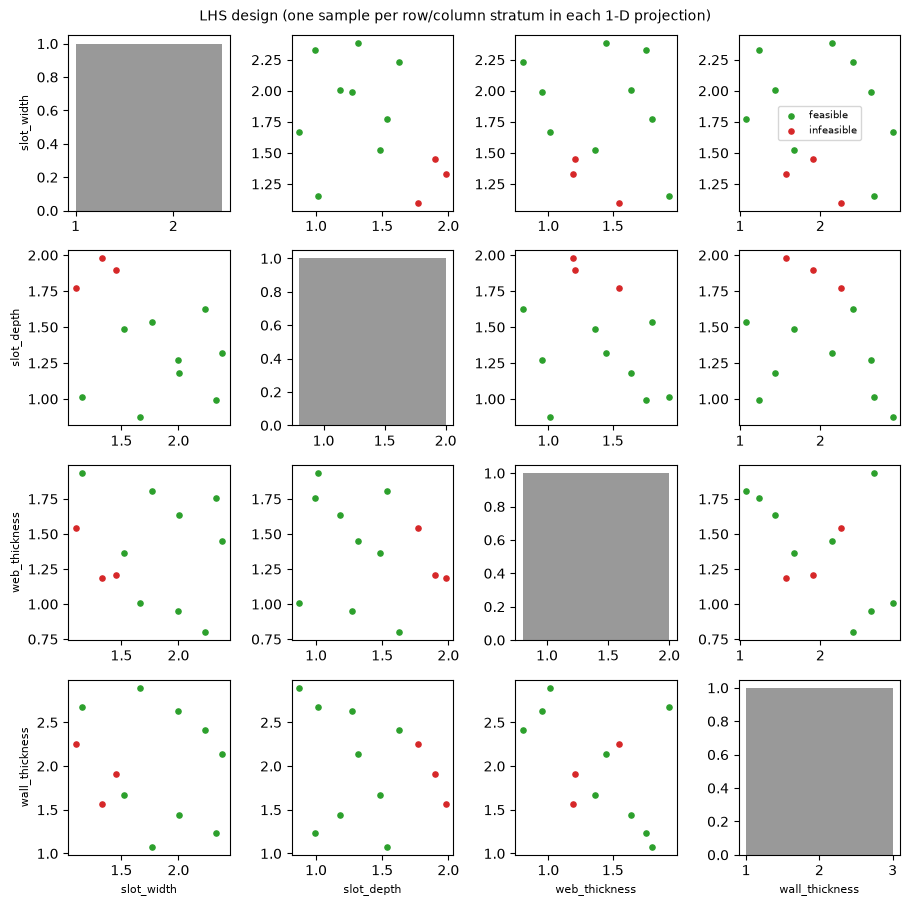

In [14]:
LHS_BOUNDS = {
    "slot_width":     (1.0, 2.5),
    "slot_depth":     (0.8, 2.0),
    "web_thickness":  (0.8, 2.0),
    "wall_thickness": (1.0, 3.0),
    # "enrichment":   (5.0, 33.477),   # optional: U-235 wt% of U (off -> ENRICHMENT for every sample)
    # "core_radius":  (50.0, 100.0),   # optional: cylinder radius R in cm, H = 2R (off -> CORE_RADIUS)
}
FIXED = {}                  # e.g. {"wall_thickness": 2.0}
N_SAMPLES, LHS_SEED = 12, 2026
LHS_DIR = os.path.join(WORK_DIR, "lhs_runs")

samples = lhs_samples({k: v for k, v in LHS_BOUNDS.items() if k not in FIXED}, N_SAMPLES, seed=LHS_SEED,
                      fixed=FIXED, geometry_opts=GEOM_OPTS, defaults={"enrichment": ENRICHMENT, "core_radius": CORE_RADIUS})
print(f"{samples['feasible'].sum()} / {len(samples)} samples feasible")
display(samples.round(3))

free = [k for k in ALL_PARAMS if k in LHS_BOUNDS and k not in FIXED]
fig, axs = plt.subplots(len(free), len(free), figsize=(2.3 * len(free), 2.3 * len(free)), squeeze=False)
for i, a in enumerate(free):
    for j, b in enumerate(free):
        ax = axs[i, j]
        if i == j:
            ax.hist(samples[a], bins=N_SAMPLES, range=LHS_BOUNDS[a], color="0.6")
        else:
            for f, c in [(True, "tab:green"), (False, "tab:red")]:
                s = samples[samples["feasible"] == f]
                ax.scatter(s[b], s[a], s=14, c=c, label="feasible" if f else "infeasible")
        if i == len(free) - 1: ax.set_xlabel(b, fontsize=8)
        if j == 0: ax.set_ylabel(a, fontsize=8)
axs[0, -1].legend(fontsize=7)
fig.suptitle("LHS design (one sample per row/column stratum in each 1-D projection)", fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_design.png"), dpi=130); plt.show()

In [15]:
do_run = RUN_TRANSPORT and HAVE_XS
if RUN_TRANSPORT and not HAVE_XS:
    print("RUN_TRANSPORT requested but no cross_sections.xml -> building models + analytic metrics only")
results = run_lhs(samples, LHS_DIR, geometry_opts=GEOM_OPTS_CORE, run_opts=RUN_OPTS, run_transport=do_run, threads=THREADS)
csv_path = os.path.join(WORK_DIR, "lhs_results.csv")
results.to_csv(csv_path)
print("saved", csv_path)
display(results[list(ALL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_vf", "graphite_to_fuel", "keff", "keff_std", "runtime_s", "status"]].round(4))

sample   1: slot_width=1.154, slot_depth=1.015, web_thickness=1.937, wall_thickness=2.672, enr=33.48, R=70.0 | fuel_vf=0.049 C/F=18.40 | built
sample   3: slot_width=1.770, slot_depth=1.534, web_thickness=1.807, wall_thickness=1.076, enr=33.48, R=70.0 | fuel_vf=0.098 C/F=8.22 | built
sample   4: slot_width=2.235, slot_depth=1.625, web_thickness=0.800, wall_thickness=2.411, enr=33.48, R=70.0 | fuel_vf=0.179 C/F=3.60 | built
sample   5: slot_width=1.521, slot_depth=1.487, web_thickness=1.361, wall_thickness=1.669, enr=33.48, R=70.0 | fuel_vf=0.106 C/F=7.44 | built
sample   7: slot_width=2.005, slot_depth=1.181, web_thickness=1.639, wall_thickness=1.436, enr=33.48, R=70.0 | fuel_vf=0.102 C/F=7.76 | built
sample   8: slot_width=2.325, slot_depth=0.993, web_thickness=1.758, wall_thickness=1.239, enr=33.48, R=70.0 | fuel_vf=0.098 C/F=8.21 | built
sample   9: slot_width=2.383, slot_depth=1.316, web_thickness=1.447, wall_thickness=2.142, enr=33.48, R=70.0 | fuel_vf=0.123 C/F=6.14 | built
sampl

sample  11: slot_width=1.667, slot_depth=0.872, web_thickness=1.011, wall_thickness=2.899, enr=33.48, R=70.0 | fuel_vf=0.102 C/F=7.78 | built
saved /workspace/msr_slab/lhs_results.csv


,slot_width,slot_depth,web_thickness,wall_thickness,enrichment,core_radius,fuel_vf,coolant_vf,graphite_vf,graphite_to_fuel,keff,keff_std,runtime_s,status
sample,,,,,,,,,,,,,,
1,1.1539,1.0146,1.9368,2.6722,33.477,70.0,0.0490,0.0490,0.9020,18.4033,NaN,NaN,NaN,built
3,1.7700,1.5340,1.8070,1.0759,33.477,70.0,0.0978,0.0978,0.8044,8.2225,NaN,NaN,NaN,built
4,2.2354,1.6248,0.8002,2.4106,33.477,70.0,0.1786,0.1786,0.6429,3.6000,NaN,NaN,NaN,built
5,1.5210,1.4867,1.3612,1.6693,33.477,70.0,0.1060,0.1060,0.7880,7.4350,NaN,NaN,NaN,built
7,2.0050,1.1808,1.6390,1.4362,33.477,70.0,0.1025,0.1025,0.7950,7.7574,NaN,NaN,NaN,built
8,2.3248,0.9929,1.7576,1.2389,33.477,70.0,0.0980,0.0980,0.8040,8.2054,NaN,NaN,NaN,built
9,2.3826,1.3161,1.4474,2.1423,33.477,70.0,0.1228,0.1228,0.7543,6.1401,NaN,NaN,NaN,built
10,1.9944,1.2685,0.9479,2.6349,33.477,70.0,0.1407,0.1407,0.7186,5.1064,NaN,NaN,NaN,built
11,1.6673,0.8717,1.0113,2.8994,33.477,70.0,0.1023,0.1023,0.7954,7.7774,NaN,NaN,NaN,built


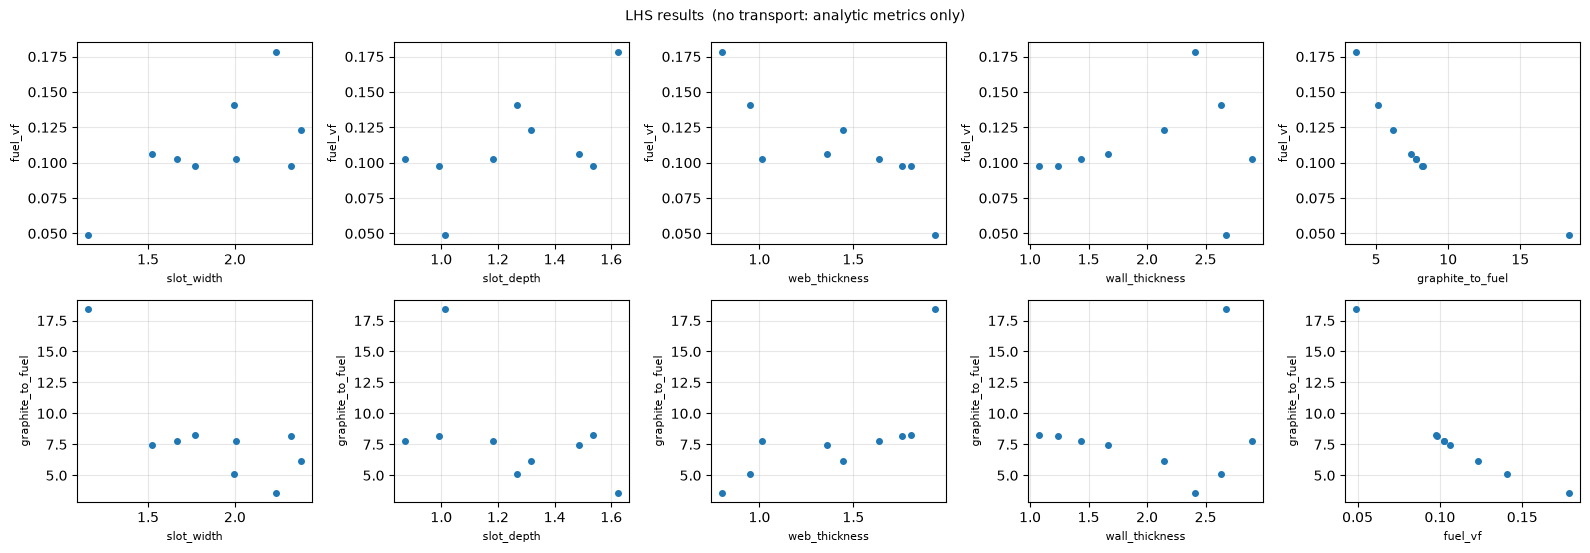

In [16]:
have_k = results["keff"].notna().any()
XCOLS = list(PARAM_NAMES) + [c for c in OPTIONAL_PARAMS if results[c].nunique() > 1]
ycols = ["keff"] if have_k else []
ycols += ["fuel_vf", "graphite_to_fuel"]
fig, axs = plt.subplots(len(ycols), len(XCOLS) + 1, figsize=(3.2 * (len(XCOLS) + 1), 2.8 * len(ycols)), squeeze=False)
for r, y in enumerate(ycols):
    for c, x in enumerate(XCOLS + ["graphite_to_fuel"] if y != "graphite_to_fuel" else XCOLS + ["fuel_vf"]):
        ax = axs[r, c]
        if y == "keff":
            ax.errorbar(results[x], results["keff"], yerr=results["keff_std"], fmt="o", ms=4, capsize=2)
        else:
            ax.plot(results[x], results[y], "o", ms=4)
        ax.set_xlabel(x, fontsize=8); ax.set_ylabel(y, fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("LHS results" + ("" if have_k else "  (no transport: analytic metrics only)"), fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_results.png"), dpi=130); plt.show()

# LHS summary (9 feasible of 12 samples, seed 2026)

Lengths in cm. round_location=side, n_slot_pairs=2, mode=cylinder, R=70.0 cm (H=2R) unless varied, reflector=0.0 cm, enrichment 33.477 wt% U-235 unless varied, T = 922.0 K, 10000 particles x 100 batches (40 inactive), library: /workspace/nucdata/endfb-viii.0-hdf5/cross_sections.xml

| sample | slot_width | slot_depth | web_thickness | wall_thickness | enrichment | core_radius | fuel_vf | coolant_vf | graphite_to_fuel | keff | keff_std_pcm | runtime_s | status |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 1.154 | 1.015 | 1.937 | 2.672 | 33.477 | 70.0 | 0.0490 | 0.0490 | 18.40 | - | - | - | built |
| 3 | 1.770 | 1.534 | 1.807 | 1.076 | 33.477 | 70.0 | 0.0978 | 0.0978 | 8.22 | - | - | - | built |
| 4 | 2.235 | 1.625 | 0.800 | 2.411 | 33.477 | 70.0 | 0.1786 | 0.1786 | 3.60 | - | - | - | built |
| 5 | 1.521 | 1.487 | 1.361 | 1.669 | 33.477 | 70.0 | 0.1060 | 0.1060 | 7.44 | - | - | - | built |
| 7 | 2.005 | 1.181 | 1.63

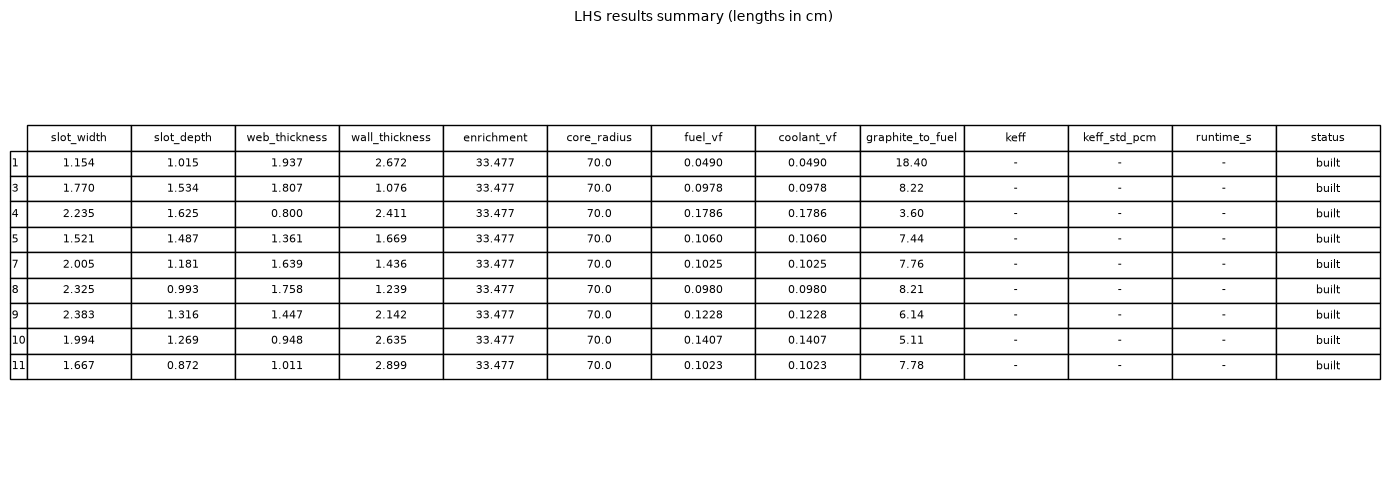

In [17]:
# keff vs each parameter (own figure) + summary table (markdown + PNG)
if have_k:
    xs = XCOLS + ["graphite_to_fuel"]
    fig, axs = plt.subplots(1, len(xs), figsize=(3.4 * len(xs), 3.4), sharey=True)
    for ax, x in zip(axs, xs):
        ax.errorbar(results[x], results["keff"], yerr=results["keff_std"], fmt="o", ms=5, capsize=3)
        for i, r in results.iterrows():
            ax.annotate(str(i), (r[x], r["keff"]), fontsize=6, xytext=(3, 3), textcoords="offset points")
        ax.set_xlabel(x + (" [cm]" if x in PARAM_NAMES else " [U-235 wt%]" if x == "enrichment" else " [cm]" if x == "core_radius" else " (V_gr / V_fuel)")); ax.grid(alpha=0.3)
    axs[0].set_ylabel("k-eff" if MODE == "cylinder" else "k-inf")
    fig.suptitle(f"{'finite-cylinder k-eff' if MODE == 'cylinder' else 'k-inf'} vs parameters (LHS, {len(results)} feasible samples, {PARTICLES} particles x {BATCHES-INACTIVE} active batches)", fontsize=10)
    fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "keff_vs_params.png"), dpi=140); plt.show()

cols = list(ALL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_to_fuel", "keff", "keff_std", "runtime_s", "status"]
summ = results[cols].copy()
summ["keff_std_pcm"] = summ["keff_std"] * 1e5
summ = summ[list(ALL_PARAMS) + ["fuel_vf", "coolant_vf", "graphite_to_fuel", "keff", "keff_std_pcm", "runtime_s", "status"]]
fmt = {c: "{:.3f}" for c in PARAM_NAMES} | {"enrichment": "{:.3f}", "core_radius": "{:.1f}", "runtime_s": "{:.0f}", "fuel_vf": "{:.4f}", "coolant_vf": "{:.4f}", "graphite_to_fuel": "{:.2f}",
                                          "keff": "{:.5f}", "keff_std_pcm": "{:.0f}"}
tbl = summ.copy()
for c, f in fmt.items():
    tbl[c] = [f.format(v) if pd.notna(v) else "-" for v in summ[c]]
md_path = os.path.join(WORK_DIR, "lhs_summary.md")
with open(md_path, "w") as fh:
    fh.write(f"# LHS summary ({len(results)} feasible of {len(samples)} samples, seed {LHS_SEED})\n\n")
    fh.write(f"Lengths in cm. round_location={GEOM_OPTS['round_location']}, n_slot_pairs={GEOM_OPTS['n_slot_pairs']}, "
             f"mode={MODE}, R={CORE_RADIUS} cm (H=2R) unless varied, reflector={REFLECTOR_THICKNESS} cm, "
             f"enrichment {ENRICHMENT} wt% U-235 unless varied, T = {TEMPERATURE_K} K, "
             f"{PARTICLES} particles x {BATCHES} batches ({INACTIVE} inactive), library: {openmc.config.get('cross_sections') if HAVE_XS else 'none'}\n\n")
    hdr = ["sample"] + list(tbl.columns)                      # plain markdown table (no 'tabulate' dependency)
    fh.write("| " + " | ".join(hdr) + " |\n|" + "---|" * len(hdr) + "\n")
    for i, r in tbl.iterrows():
        fh.write("| " + " | ".join([str(i)] + [str(v) for v in r.values]) + " |\n")
    fh.write("\n")
print(open(md_path).read())
fig, ax = plt.subplots(figsize=(14, 0.45 * (len(tbl) + 2)))
ax.axis("off")
t = ax.table(cellText=tbl.values, colLabels=list(tbl.columns), rowLabels=[str(i) for i in tbl.index], loc="center", cellLoc="center")
t.auto_set_font_size(False); t.set_fontsize(8); t.scale(1, 1.3)
ax.set_title("LHS results summary (lengths in cm)", fontsize=10)
fig.tight_layout(); fig.savefig(os.path.join(WORK_DIR, "lhs_summary_table.png"), dpi=150); plt.show()

## Notes / next steps
* Raise `PARTICLES`/`BATCHES` (e.g. 20 000 × 150) and `N_SAMPLES` for real studies; each unit-cell run is independent → trivially parallel.
* Useful extra outputs to add per sample: fuel/coolant temperature coefficients (re-run at ±ΔT), conversion ratio (tally U-238 capture / U-235 absorption), spectrum.
* `mode="unit_cell"` gives the quick periodic k-inf model; `reflector_thickness` adds graphite around the cylinder.
* To use different fuel/coolant slot sizes, split `slot_width`/`slot_depth` in `resolve_params()`/`build_unit_universe()` — the profile builder already takes them per slot.